In [45]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from math import ceil
import random

=== ПРИМЕР ДЛЯ p = 0.5 ===
Количество 2x2 блоков M = 13
Закрашено вершин: 41
Рёбер в графе: 55
Размер матрицы смежности: 41 x 41


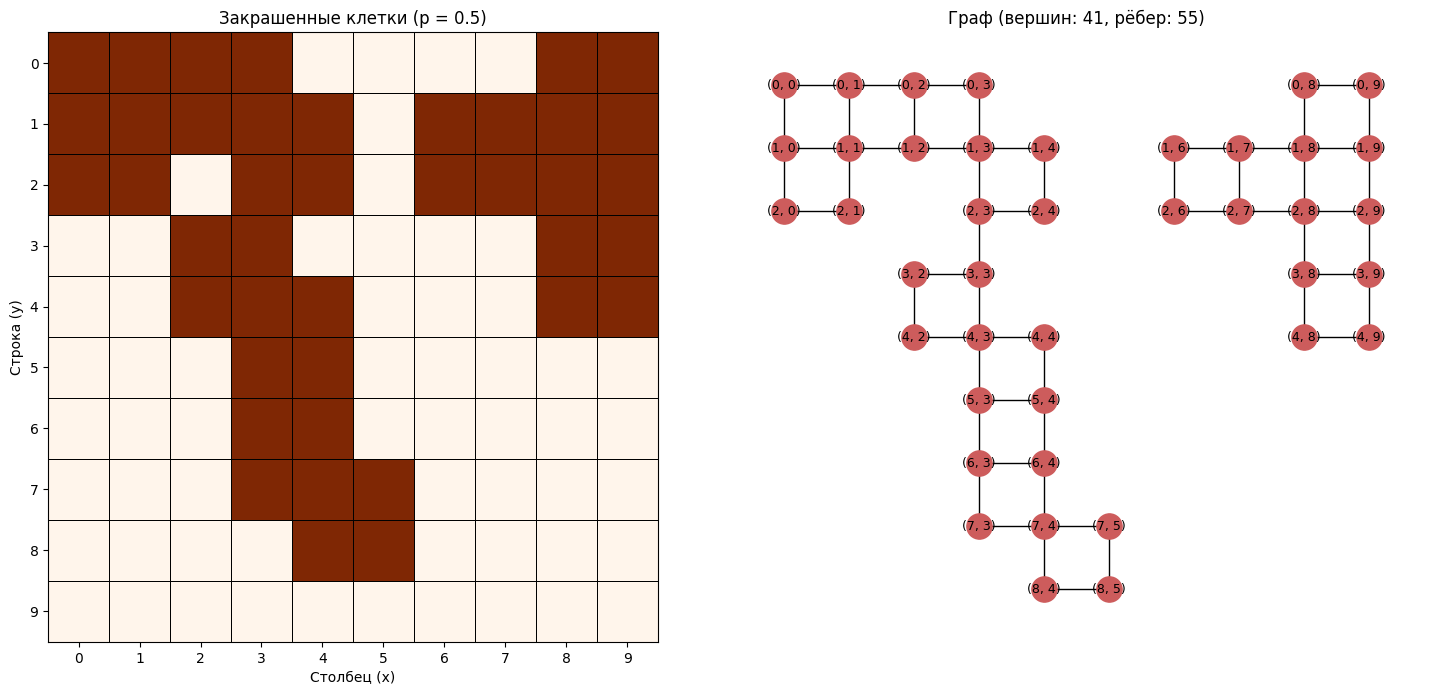

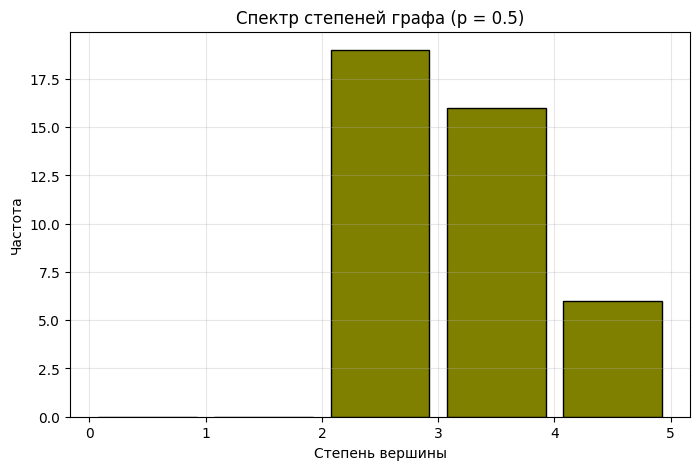

In [46]:
# ====================== ФУНКЦИИ ДЛЯ ВАРИАНТА 10 ======================
def generate_painted_cells(N=10, p=0.5, seed=None):
    """Генерируем закрашенные клетки с помощью 2x2 блоков"""
    if seed is not None:
        random.seed(seed)
    
    M = ceil(p * N**2 / 4)                    # сколько 2x2 блоков бросаем
    painted = set()                           # множество закрашенных клеток
    
    for _ in range(M):
        r = random.randint(0, N-2)            # верхний левый угол: 0..8
        c = random.randint(0, N-2)
        # закрашиваем 4 клетки блока
        for dr in [0, 1]:
            for dc in [0, 1]:
                painted.add((r + dr, c + dc))
    return painted, M

def build_grid_graph(painted):
    """Строим граф: вершины = закрашенные клетки, рёбра = горизонт/вертикаль"""
    G = nx.Graph()
    G.add_nodes_from(painted)
    
    directions = [(0, 1), (1, 0)]   # вправо и вниз (undirected)
    for i, j in painted:
        for di, dj in directions:
            ni, nj = i + di, j + dj
            if (ni, nj) in painted:
                G.add_edge((i, j), (ni, nj))
    return G

# ====================== ПРИМЕР ДЛЯ p=0.5 (пункты 2 и 3) ======================
N = 10
p_example = 0.5
painted, M = generate_painted_cells(N, p_example, seed=42)   # seed для повторяемости
G = build_grid_graph(painted)

print(f"=== ПРИМЕР ДЛЯ p = {p_example} ===")
print(f"Количество 2x2 блоков M = {M}")
print(f"Закрашено вершин: {len(painted)}")
print(f"Рёбер в графе: {G.number_of_edges()}")
print(f"Размер матрицы смежности: {len(G.nodes)} x {len(G.nodes)}")

# Визуализация
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

# 1. Карта закрашенных клеток
# Вместо grid = np.zeros((N, N)) ...
# Используйте pcolormesh:
# Создаем сетку координат для краев ячеек
x = np.arange(N + 1)
y = np.arange(N + 1)

# Pcolormesh рисует ячейки точно между координатами
axs[0].pcolormesh(x, y, grid, cmap='Oranges', edgecolors='black', linewidth=0.5)

# Инвертируем Y, чтобы 0,0 был в левом верхнем углу, как в матрице
axs[0].invert_yaxis()

# Настройки оформления
axs[0].set_title(f'Закрашенные клетки (p = {p_example})')
axs[0].set_xlabel('Столбец (x)')
axs[0].set_ylabel('Строка (y)')
axs[0].set_xticks(np.arange(N) + 0.5, labels=np.arange(N))
axs[0].set_yticks(np.arange(N) + 0.5, labels=np.arange(N))
axs[0].set_aspect('equal')

# Граф
pos = {(r, c): (c, N-1-r) for r, c in G.nodes()}
nx.draw(G, pos=pos, ax=axs[1], node_size=330, node_color='indianred',
        edge_color='black', with_labels=True, font_size=9)
axs[1].set_title(f'Граф (вершин: {len(G.nodes)}, рёбер: {G.number_of_edges()})')

plt.tight_layout()
plt.show()

# Спектр степеней
degrees = [d for _, d in G.degree()]
plt.figure(figsize=(8, 5))
plt.hist(degrees, bins=range(0, max(degrees)+2), rwidth=0.85, color='olive', edgecolor='black')
plt.title(f'Спектр степеней графа (p = {p_example})')
plt.xlabel('Степень вершины')
plt.ylabel('Частота')
plt.grid(True, alpha=0.3)
plt.show()

Вычисляем вероятности пути слева направо...
p = 0.00  →  вероятность = 0.000
p = 0.05  →  вероятность = 0.000
p = 0.10  →  вероятность = 0.000
p = 0.15  →  вероятность = 0.000
p = 0.20  →  вероятность = 0.000
p = 0.25  →  вероятность = 0.000
p = 0.30  →  вероятность = 0.003
p = 0.35  →  вероятность = 0.004
p = 0.40  →  вероятность = 0.016
p = 0.45  →  вероятность = 0.053
p = 0.50  →  вероятность = 0.066
p = 0.55  →  вероятность = 0.120
p = 0.60  →  вероятность = 0.217
p = 0.65  →  вероятность = 0.287
p = 0.70  →  вероятность = 0.287
p = 0.75  →  вероятность = 0.389
p = 0.80  →  вероятность = 0.410
p = 0.85  →  вероятность = 0.544
p = 0.90  →  вероятность = 0.624
p = 0.95  →  вероятность = 0.666
p = 1.00  →  вероятность = 0.696


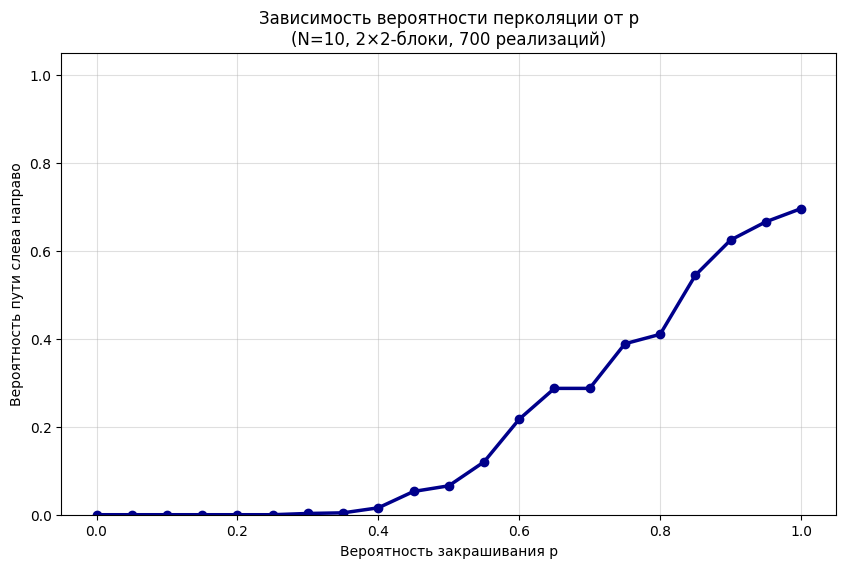

In [47]:
def has_left_right_path(G, N=10):
    """Проверяем, есть ли путь между 1-м и последним столбцами"""
    if len(G) == 0:
        return False
    for comp in nx.connected_components(G):
        has_left = any(node[1] == 0 for node in comp)      # столбец 0
        has_right = any(node[1] == N-1 for node in comp)   # столбец 9
        if has_left and has_right:
            return True
    return False

# ====================== ГРАФИК ВЕРОЯТНОСТИ (пункт 4) ======================
p_values = np.arange(0.0, 1.01, 0.05)
num_trials = 700                     # количество реализаций (можно увеличить)
probs = []

print("Вычисляем вероятности пути слева направо...")
for p in p_values:
    successes = 0
    for trial in range(num_trials):
        painted_t, _ = generate_painted_cells(N, p)   # каждый раз новый случай
        G_t = build_grid_graph(painted_t)
        if has_left_right_path(G_t, N):
            successes += 1
    prob = successes / num_trials
    probs.append(prob)
    print(f"p = {p:.2f}  →  вероятность = {prob:.3f}")

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(p_values, probs, 'o-', linewidth=2.5, markersize=6, color='darkblue')
plt.xlabel('Вероятность закрашивания p')
plt.ylabel('Вероятность пути слева направо')
plt.title(f'Зависимость вероятности перколяции от p\n(N=10, 2×2-блоки, {num_trials} реализаций)')
plt.grid(True, alpha=0.4)
plt.ylim(0, 1.05)
plt.show()